<a href="https://colab.research.google.com/github/prof-atritiack/1CC-SERS-CP2-2SEM/blob/main/Exemplo_Final_Aula_06_1CCA_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exemplo de treinamento e avaliação de um modelo preditivo de classificação**

# Preparação do ambiente

In [4]:

import pandas as pd

# Ferramentas para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas para Modelagem (utilizar 3 algoritmos do sklearn)

# Separação de dados de treinamento e teste
from sklearn.model_selection import train_test_split

# Algoritmos para classicação
# Regressão Logística
from sklearn.linear_model import LogisticRegression
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Avaliação dos modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Carga dos dados

In [5]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/1CC-SERS-CP2-2SEM/refs/heads/main/datasets/Data_for_UCI_named.csv')

# Análise Exploratória

In [6]:
dados.head(20)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [8]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [9]:
# Estatística de colunas categóricas
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [10]:
# Lista das categorias da coluna alvo
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [11]:
# Contagem das categorias da coluna 'stabf' (coluna alvo ---> target)
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [12]:
# Definição de dados de entrada (Features ou Variáveis Independentes)
# e dados de saída (Target ou Variável Dependente)
# X (maiúsculo) ----> entrada
# y (minúsculo) ----> saída

In [13]:
X = dados.drop(columns=['stab', 'stabf'])
y = dados['stabf']

In [14]:
type(X)

pandas.core.frame.DataFrame

In [15]:
X

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391


In [16]:
type(y)

pandas.core.series.Series

In [17]:
y

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable
...,...
9995,unstable
9996,stable
9997,stable
9998,unstable


# Separação de dados de treinamento e teste

X_train, X_test, y_train, y_test

In [18]:
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [19]:
# SEED ---> random_state ---> parâmetro para "fixar" a amostra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [20]:
# Instanciando o primeiro (LogisticRegression)
modelo_LR = LogisticRegression()

In [21]:
# Treinamento do modelo
modelo_LR.fit(X_train, y_train)

LogisticRegression()

In [29]:
# Geração das probabilidades
probabilidades = modelo_LR.predict_proba(X_test)
probabilidades[:50]

array([[0.03825818, 0.96174182],
       [0.18760004, 0.81239996],
       [0.85964922, 0.14035078],
       [0.8889158 , 0.1110842 ],
       [0.02299536, 0.97700464],
       [0.9086316 , 0.0913684 ],
       [0.07714869, 0.92285131],
       [0.10140089, 0.89859911],
       [0.19258966, 0.80741034],
       [0.92089189, 0.07910811],
       [0.02648338, 0.97351662],
       [0.96382519, 0.03617481],
       [0.17703937, 0.82296063],
       [0.84515051, 0.15484949],
       [0.05981379, 0.94018621],
       [0.30590534, 0.69409466],
       [0.42881637, 0.57118363],
       [0.02138358, 0.97861642],
       [0.77277877, 0.22722123],
       [0.38408291, 0.61591709],
       [0.25730871, 0.74269129],
       [0.21253236, 0.78746764],
       [0.01101105, 0.98898895],
       [0.55511496, 0.44488504],
       [0.5941227 , 0.4058773 ],
       [0.03729827, 0.96270173],
       [0.03018877, 0.96981123],
       [0.81818048, 0.18181952],
       [0.08051674, 0.91948326],
       [0.21380298, 0.78619702],
       [0.

In [28]:
# Geração de previsões
y_predict = modelo_LR.predict(X_test)
y_predict[:50]

array(['unstable', 'unstable', 'stable', 'stable', 'unstable', 'stable',
       'unstable', 'unstable', 'unstable', 'stable', 'unstable', 'stable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'stable', 'unstable', 'unstable', 'stable',
       'unstable', 'unstable', 'unstable', 'unstable', 'unstable',
       'stable', 'unstable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable', 'stable',
       'unstable'], dtype=object)

In [24]:
# Avaliação do modelo
'''
Gerar comandos para as métricas do modelo
treinado usando seaborn e matplotlib.
Crie gráficos auxiliares e tabelas contendo todas as métricas que importamos na célula inicial. incluindo classification report.
'''

'\nGerar comandos para as métricas do modelo\ntreinado usando seaborn e matplotlib.\nCrie gráficos auxiliares e tabelas contendo todas as métricas que importamos na célula inicial. incluindo classification report.\n'

### Métricas de Avaliação do Modelo

In [25]:
print('Métricas de Avaliação para Regressão Logística:')
print(f'Acurácia: {accuracy_score(y_test, y_predict):.2f}')
print(f'Precisão: {precision_score(y_test, y_predict, pos_label="unstable"):.2f}')
print(f'Recall: {recall_score(y_test, y_predict, pos_label="unstable"):.2f}')
print(f'F1-Score: {f1_score(y_test, y_predict, pos_label="unstable"):.2f}')

Métricas de Avaliação para Regressão Logística:
Acurácia: 0.80
Precisão: 0.84
Recall: 0.86
F1-Score: 0.85


### Matriz de Confusão

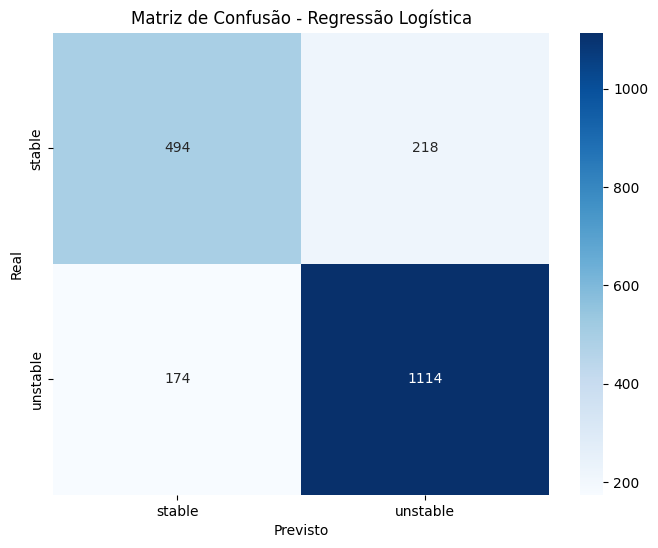

In [26]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo_LR.classes_, yticklabels=modelo_LR.classes_)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

### Relatório de Classificação

In [27]:
print('Relatório de Classificação para Regressão Logística:')
print(classification_report(y_test, y_predict))

Relatório de Classificação para Regressão Logística:
              precision    recall  f1-score   support

      stable       0.74      0.69      0.72       712
    unstable       0.84      0.86      0.85      1288

    accuracy                           0.80      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.80      0.80      0.80      2000



##MODELO DE REGRESSÃO LINEAR

In [30]:
# Classe LinearRegression
from sklearn.linear_model import LinearRegression

In [31]:
# Target
y = dados['stab']

In [ ]:
# Quais são os atributos que tem maior correlação com atributo alvo (target)
# Monte uma matriz de correlação de todas as variáveis do dataframe 'dados'
# usando heatmap


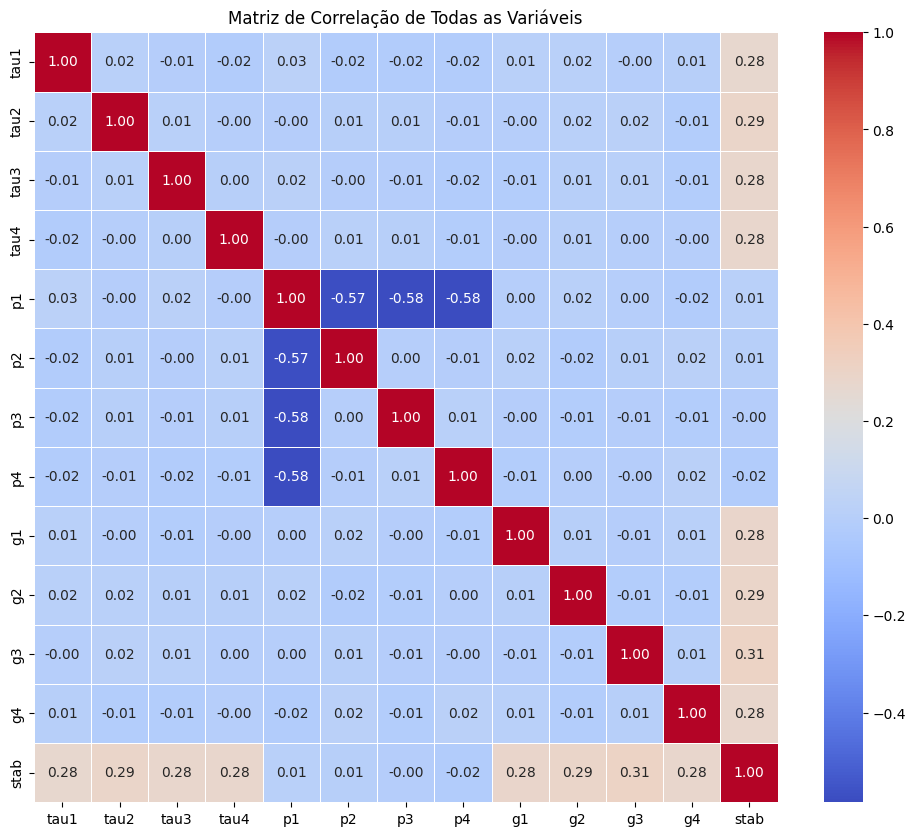

In [34]:
correlation_matrix = dados.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação de Todas as Variáveis')
plt.show()

In [35]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [36]:
# Definindo dataframe com as features
X = dados[['g1', 'g2', 'g3', 'g4']]
X.head()

,g1,g2,g3,g4
0,0.650456,0.859578,0.887445,0.958034
1,0.413441,0.862414,0.562139,0.781760
2,0.163041,0.766689,0.839444,0.109853
3,0.446209,0.976744,0.929381,0.362718
4,0.797110,0.455450,0.656947,0.820923


In [37]:
modeloRL = LinearRegression()